[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter10_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 10: Market Microstructure

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: derivations (A1–A10); Part B: estimation and inference (B1–B8); Part C: open question.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # doar linii de referinta
GROUP_COL = {'US': MainBlue, 'BVB': IDAred, 'Crypto': Amber}

HERE = '.'
SEED = 42
START2 = '2024-09-19'
START10 = '2016-09-19'
B_BOOT = 1000



def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o

## Data

- SPY 5-minute bars, regular session (09:30–16:00 New York time), October 2020 – September 2026; Bitcoin 5-minute bars (UTC), September 2024 – September 2026.
- Daily open, high, low, close and volume for US stocks, Bucharest Stock Exchange (BVB) stocks and crypto-assets; prices adjusted for dividends and splits.
- BVB traded values converted from lei to USD at the BNR reference rate; crypto traded values are in USD.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# cheie -> (simbol, eticheta, grup)
ASSETS = {
    'SPY': ('SPY.US', 'SPY', 'US'), 'AAPL': ('AAPL.US', 'Apple', 'US'), 'MSFT': ('MSFT.US', 'Microsoft', 'US'),
    'NVDA': ('NVDA.US', 'NVIDIA', 'US'), 'JPM': ('JPM.US', 'JPMorgan', 'US'), 'GME': ('GME.US', 'GameStop', 'US'),
    'MSTR': ('MSTR.US', 'Strategy', 'US'),
    'TLV': ('TLV.RO', 'Banca Transilvania', 'BVB'), 'SNP': ('SNP.RO', 'OMV Petrom', 'BVB'),
    'H2O': ('H2O.RO', 'Hidroelectrica', 'BVB'), 'BRD': ('BRD.RO', 'BRD', 'BVB'), 'SNG': ('SNG.RO', 'Romgaz', 'BVB'),
    'SNN': ('SNN.RO', 'Nuclearelectrica', 'BVB'), 'TGN': ('TGN.RO', 'Transgaz', 'BVB'),
    'EL': ('EL.RO', 'Electrica', 'BVB'), 'DIGI': ('DIGI.RO', 'Digi', 'BVB'), 'TEL': ('TEL.RO', 'Transelectrica', 'BVB'),
    'TVBETETF': ('TVBETETF.RO', 'BET ETF', 'BVB'),
    'BTC': ('BTC-USD.CC', 'Bitcoin', 'Crypto'), 'ETH': ('ETH-USD.CC', 'Ethereum', 'Crypto'),
    'SOL': ('SOL-USD.CC', 'Solana', 'Crypto'), 'XRP': ('XRP-USD.CC', 'XRP', 'Crypto'),
    'DOGE': ('DOGE-USD.CC', 'Dogecoin', 'Crypto'), 'ADA': ('ADA-USD.CC', 'Cardano', 'Crypto'),
    'LTC': ('LTC-USD.CC', 'Litecoin', 'Crypto'),
}
GROUPS = {g: [k for k, v in ASSETS.items() if v[2] == g] for g in ('US', 'BVB', 'Crypto')}
LABELS = {k: v[1] for k, v in ASSETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    if symbol in _CACHE:
        return _CACHE[symbol]
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    _CACHE[symbol] = pd.read_csv(src, index_col='date', parse_dates=True).sort_index()
    return _CACHE[symbol]


def read_reference_rate(currency='USD', start='2014-01-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = ('REF', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'rate']).drop_duplicates('date').set_index('date')['rate']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def _clean(key, d):
    d = d[(d['high'] > d['low']) & (d['volume'].fillna(0) > 0)]
    if ASSETS[key][2] != 'Crypto':
        d = d[d.index.dayofweek < 5]
        # cotatii eronate izolate: pretul ajustat de peste doua ori mai mare / mai mic decat mediana locala (21 de zile)
        med = d['adjusted_close'].rolling(21, center=True, min_periods=5).median()
        d = d[np.abs(np.log(d['adjusted_close'] / med)) < np.log(2)]
    return d


def ohlc(key, start='2016-09-19', end=END):
    """Deschidere, maxim, minim, inchidere ajustate cu factorul pretului ajustat (dividende si split-uri)."""
    d = read_market(ASSETS[key][0]).loc[start:end].copy()
    f = d['adjusted_close'] / d['close']
    for c in ['open', 'high', 'low', 'close']:
        d[c] = d[c] * f
    return _clean(key, d)[['open', 'high', 'low', 'close', 'volume']]


def split_adjusted_close(d):
    """Pretul de inchidere ajustat DOAR pentru split-uri (aceeasi baza ca volumul in numar de actiuni)."""
    k = (d['close'].shift(1) / d['close']) / (d['adjusted_close'].shift(1) / d['adjusted_close'])
    k = k.where(np.abs(np.log(k)) > 0.15, 1.0).fillna(1.0)      # zilele de split: raportul de divizare
    back = k[::-1].cumprod()[::-1].shift(-1).fillna(1.0)          # produsul split-urilor ulterioare fiecarei zile
    return d['close'] / back


def returns(key, start='2016-09-19', end=END):
    """Randamente log zilnice din pretul ajustat (zilele fara tranzactii eliminate)."""
    d = read_market(ASSETS[key][0]).loc[start:end]
    d = _clean(key, d)
    return np.log(d['adjusted_close']).diff().dropna().rename(key)


def dollar_volume(key, start='2016-09-19', end=END):
    """Valoarea tranzactionata zilnic, in USD."""
    d = read_market(ASSETS[key][0]).loc[:end]
    grp = ASSETS[key][2]
    if grp == 'Crypto':
        dv = d['volume']                                          # deja in USD
    else:
        dv = split_adjusted_close(d) * d['volume']
        if grp == 'BVB':                                          # RON -> USD la cursul de referinta BNR
            fx = read_reference_rate('USD', start='2014-01-01', end=end)
            dv = dv / fx.reindex(dv.index).ffill()
    d = _clean(key, d.assign(dv=dv))
    return d['dv'].loc[start:end].dropna().rename(key)


def intraday_spy():
    """Bare de 5 minute SPY, sesiunea regulata (09:30-15:55 = inceputul barei), doar zilele complete (78 de bare)."""
    fname = 'intraday/SPY.US_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    t = d['datetime_utc'].dt.tz_localize('UTC').dt.tz_convert('America/New_York').dt.tz_localize(None)
    d = d.assign(t=t, date=t.dt.normalize(), tod=t.dt.strftime('%H:%M')).drop(columns='datetime_utc')
    d = d[(d['tod'] >= '09:30') & (d['tod'] <= '15:55')]
    n = d.groupby('date').size()
    d = d[d['date'].isin(n[n == 78].index)].set_index('t').sort_index()
    d['r'] = np.log(d['close']).groupby(d['date']).diff()
    first = d['tod'] == '09:30'
    d.loc[first, 'r'] = np.log(d.loc[first, 'close'] / d.loc[first, 'open'])   # prima bara: de la deschidere
    d['dv'] = d['close'] * d['volume']
    return d


def intraday_btc():
    """Bare de 5 minute Bitcoin (UTC), 24 de ore din 24; volumul nu este folosit (lipseste pe multe bare)."""
    fname = 'intraday/BTC-USD.CC_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    d = pd.read_csv(path if os.path.exists(path) else REPO_RAW + fname, parse_dates=['datetime_utc'])
    d = d.set_index('datetime_utc').sort_index()
    d = d[~d.index.duplicated()]
    d['date'] = d.index.normalize()
    d['r'] = np.log(d['close']).diff()
    gap = d.index.to_series().diff() != pd.Timedelta('5min')
    d.loc[gap, 'r'] = np.nan                                       # fara randamente peste goluri
    return d

## Estimators and models

- `roll_spread`, `cs_spread`, `ar_terms`, `edge_spread`, `amihud`: spread and illiquidity measures; `roll_mc`: Monte Carlo of the Roll model.
- `price_discovery`: VECM information shares; `pin_loglik`: the PIN likelihood in stable form.
- `walk_book`, `zi_simulate`: order book execution and a simulated order book.
- `gm_quotes`, `gm_simulate`, `kyle`, `ac_trajectory`, `ac_frontier`: Glosten–Milgrom, Kyle and Almgren–Chriss.

In [ ]:
def roll_spread(close):
    """Spread-ul relativ Roll din covarianta de ordinul 1 a randamentelor log; NaN daca covarianta este pozitiva."""
    r = np.log(np.asarray(close, float))
    dp = np.diff(r)
    c = np.mean((dp[1:] - dp.mean()) * (dp[:-1] - dp.mean()))
    return (2 * np.sqrt(-c) if c < 0 else np.nan), c


def cs_spread(high, low):
    """Estimatorul Corwin-Schultz pentru fiecare pereche de perioade consecutive (valorile negative devin 0)."""
    h, l = np.log(np.asarray(high, float)), np.log(np.asarray(low, float))
    beta = (h[:-1] - l[:-1]) ** 2 + (h[1:] - l[1:]) ** 2
    gamma = (np.maximum(h[:-1], h[1:]) - np.minimum(l[:-1], l[1:])) ** 2
    k = 3 - 2 * np.sqrt(2)
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    return np.clip(2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha)), 0, None)


def ar_terms(close, high, low):
    """Termenii Abdi-Ranaldo: 4 (c_t - eta_t)(c_t - eta_{t+1}); media lor estimeaza s^2."""
    c = np.log(np.asarray(close, float))
    eta = (np.log(np.asarray(high, float)) + np.log(np.asarray(low, float))) / 2
    return 4 * (c[:-1] - eta[:-1]) * (c[:-1] - eta[1:])


def ar_spread(close, high, low):
    """Spread-ul relativ Abdi-Ranaldo: sqrt(max(media termenilor, 0))."""
    m = np.mean(ar_terms(close, high, low))
    return np.sqrt(max(m, 0.0)), m


def edge_spread(open_, high, low, close, sign=True):
    """EDGE (Ardia, Guidotti si Kroencke, 2024, JFE 161, 103916): spread-ul relativ din preturile OHLC.
    Transcrierea implementarii de referinta a autorilor (pachetul bidask, licenta MIT). sign=True pastreaza semnul
    estimarii (recomandat cand se face media estimarilor pe mai multe ferestre: media ramane nedeplasata)."""
    o, h, l, c = (np.log(np.asarray(x, float)) for x in (open_, high, low, close))
    if len(o) < 3:
        return np.nan
    m = (h + l) / 2.
    h1, l1, c1, m1 = h[:-1], l[:-1], c[:-1], m[:-1]
    o, h, l, c, m = o[1:], h[1:], l[1:], c[1:], m[1:]
    r1, r2, r3, r4, r5 = m - o, o - m1, m - c1, c1 - m1, o - c1
    tau = np.where(np.isnan(h) | np.isnan(l) | np.isnan(c1), np.nan, (h != l) | (l != c1))
    po1 = tau * np.where(np.isnan(o) | np.isnan(h), np.nan, o != h)
    po2 = tau * np.where(np.isnan(o) | np.isnan(l), np.nan, o != l)
    pc1 = tau * np.where(np.isnan(c1) | np.isnan(h1), np.nan, c1 != h1)
    pc2 = tau * np.where(np.isnan(c1) | np.isnan(l1), np.nan, c1 != l1)
    pt = np.nanmean(tau)
    po = np.nanmean(po1) + np.nanmean(po2)
    pc = np.nanmean(pc1) + np.nanmean(pc2)
    if np.nansum(tau) < 2 or po == 0 or pc == 0:
        return np.nan
    d1 = r1 - np.nanmean(r1) / pt * tau
    d3 = r3 - np.nanmean(r3) / pt * tau
    d5 = r5 - np.nanmean(r5) / pt * tau
    x1 = -4. / po * d1 * r2 - 4. / pc * d3 * r4
    x2 = -4. / po * d1 * r5 - 4. / pc * d5 * r4
    e1, e2 = np.nanmean(x1), np.nanmean(x2)
    v1, v2 = np.nanmean(x1 ** 2) - e1 ** 2, np.nanmean(x2 ** 2) - e2 ** 2
    vt = v1 + v2
    s2 = (v2 * e1 + v1 * e2) / vt if vt > 0 else (e1 + e2) / 2.
    s = np.sqrt(np.abs(s2))
    return float(s * np.sign(s2)) if sign else float(s)


def amihud(r, dv, scale=1e6):
    """Iliciditatea Amihud: media |r| (puncte de baza) la 1 milion USD tranzactionat."""
    x = pd.concat([r.rename('r'), dv.rename('dv')], axis=1, join='inner').dropna()
    x = x[x['dv'] > 0]
    return float((1e4 * x['r'].abs() / (x['dv'] / scale)).mean())


def daily_estimates(d):
    """Estimatorii de spread pe o fereastra de bare (o zi de bare intraday sau o perioada de date zilnice)."""
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return pd.Series(dict(cov=cov, roll=rs, cs=cs.mean(), ar2=ar2.mean()))


def roll_mc(c, sigma, T=78, R=20000, seed=42):
    """Harris (1990): simulam modelul Roll (m_t mers aleator cu pasi N(0, sigma^2), q_t = +-1 cu prob. 1/2)
    pe T preturi si calculam covarianta de ordinul 1 a variatiilor (demediate), ca pe date reale."""
    rng = np.random.default_rng(seed)
    p = np.cumsum(rng.normal(0, sigma, (R, T)), axis=1) + c * np.where(rng.random((R, T)) < 0.5, 1, -1)
    dp = np.diff(p, axis=1)
    dm = dp - dp.mean(axis=1, keepdims=True)
    return (dm[:, 1:] * dm[:, :-1]).mean(axis=1)


def price_discovery(y, p=1):
    """VECM bivariat cu vectorul de cointegrare (1, -1) impus: dy_t = a0 + alpha (y1 - y2)_{t-1} + sum Gamma_i dy_{t-i} + e_t.
    Intoarce alpha, statisticile t, ponderea componentei Gonzalo-Granger (alpha_perp normalizat) si limitele
    ponderii informationale Hasbrouck (cele doua ordonari Cholesky)."""
    y = np.asarray(y, float)
    dy = np.diff(y, axis=0)
    z = (y[:, 0] - y[:, 1])[:-1]
    X = np.array([[1.0, z[t]] + [v for i in range(1, p + 1) for v in dy[t - i]] for t in range(p, len(dy))])
    Y = dy[p:]
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    U = Y - X @ B
    Om = U.T @ U / (len(U) - X.shape[1])
    alpha = B[1]
    se = np.sqrt(np.linalg.inv(X.T @ X)[1, 1] * np.diag(Om))
    ap = np.array([-alpha[1], alpha[0]])                       # alpha_perp: alpha' alpha_perp = 0
    cs = ap / ap.sum()
    psi = ap                                                    # randul comun al impactului pe termen lung (pana la o scala)
    IS = []
    for order in ([0, 1], [1, 0]):
        F = np.linalg.cholesky(Om[np.ix_(order, order)])
        v = (psi[order] @ F) ** 2 / (psi @ Om @ psi)
        IS.append(v[np.argsort(order)])
    IS = np.array(IS)
    return dict(alpha=alpha, t=alpha / se, cs=cs, is_lo=IS.min(axis=0), is_hi=IS.max(axis=0),
                corr=float(Om[0, 1] / np.sqrt(Om[0, 0] * Om[1, 1])), resid=U, n=len(U))


def pin_loglik(B, S, alpha, delta, mu, eb, es):
    """Log-verosimilitatea EKOP pentru o zi cu B cumparari si S vanzari, in forma factorizata care evita
    depasirea numerica (Lin si Ke, 2011): ln L = -eb - es + B ln(mu + eb) + S ln(mu + es) - ln B! - ln S!
    + ln[(1 - alpha) xb^B xs^S + alpha delta e^-mu xb^B + alpha (1 - delta) e^-mu xs^S], xb = eb / (mu + eb)."""
    from scipy.special import gammaln, logsumexp
    lxb, lxs = np.log(eb / (mu + eb)), np.log(es / (mu + es))
    terms = [np.log(1 - alpha) + B * lxb + S * lxs, np.log(alpha * delta) - mu + B * lxb,
             np.log(alpha * (1 - delta)) - mu + S * lxs]
    base = -eb - es + B * np.log(mu + eb) + S * np.log(mu + es) - gammaln(B + 1) - gammaln(S + 1)
    return float(base + logsumexp(terms)), terms


def walk_book(asks, qty):
    """Ordin de cumparare la piata de marime qty pe ofertele de vanzare asks = [(pret, cantitate), ...] crescator.
    Intoarce executiile, pretul mediu ponderat si ofertele ramase."""
    fills, left, rest = [], qty, []
    for p, q in asks:
        if left <= 0:
            rest.append((p, q))
            continue
        take = min(q, left)
        fills.append((p, take))
        left -= take
        if q > take:
            rest.append((p, q - take))
    vwap = sum(p * q for p, q in fills) / sum(q for _, q in fills)
    return fills, vwap, rest, left


def gm_quotes(theta, mu, vl, vh):
    """Cotatiile ask si bid: asteptarea valorii conditionat de o cumparare, respectiv de o vanzare.
    theta = P(V = vh), mu = ponderea investitorilor informati; cei neinformati cumpara sau vand cu prob. 1/2."""
    pb_h, pb_l = mu + (1 - mu) / 2, (1 - mu) / 2               # P(cumparare | V = vh), P(cumparare | V = vl)
    th_b = pb_h * theta / (pb_h * theta + pb_l * (1 - theta))   # P(V = vh | cumparare)
    th_s = pb_l * theta / (pb_l * theta + pb_h * (1 - theta))   # P(V = vh | vanzare)
    return vl + th_b * (vh - vl), vl + th_s * (vh - vl), th_b, th_s


def gm_simulate(mu, vl=90.0, vh=110.0, v=110.0, n=60, seed=1):
    """Un sir de tranzactii cand valoarea adevarata este v; formatorul de piata invata din fluxul de ordine."""
    rng = np.random.default_rng(seed)
    theta, rows = 0.5, []
    for t in range(n):
        ask, bid, th_b, th_s = gm_quotes(theta, mu, vl, vh)
        informed = rng.random() < mu
        buy = (v == vh) if informed else (rng.random() < 0.5)
        rows.append(dict(t=t, ask=ask, bid=bid, theta=theta, buy=buy))
        theta = th_b if buy else th_s
    return pd.DataFrame(rows)


def kyle(sigma_v, sigma_u):
    """Echilibrul Kyle: v ~ N(p0, sigma_v^2), cererea zgomotoasa u ~ N(0, sigma_u^2).
    Strategia informatului x = beta (v - p0), pretul p = p0 + lambda (x + u)."""
    beta = sigma_u / sigma_v
    lam = sigma_v / (2 * sigma_u)
    profit = sigma_v * sigma_u / 2
    return dict(beta=beta, lam=lam, profit=profit, post_var=sigma_v ** 2 / 2)


def ac_trajectory(X, T, N, sigma, eta, gamma, lam, eps=0.0):
    """Traiectoria optima de lichidare (formulele exacte in timp discret).
    X actiuni de vandut in T zile, N intervale; sigma = volatilitatea pretului (USD / zi^0.5);
    impact temporar h(v) = eps sgn + eta v; impact permanent g(v) = gamma v; lam = aversiunea la risc."""
    tau = T / N
    eta_t = eta - gamma * tau / 2
    t = np.arange(N + 1) * tau
    if lam == 0:
        x = X * (1 - t / T)
    else:
        kt2 = lam * sigma ** 2 / eta_t                       # kappa_tilde^2
        kappa = np.arccosh(kt2 * tau ** 2 / 2 + 1) / tau
        x = X * np.sinh(kappa * (T - t)) / np.sinh(kappa * T)
    n = -np.diff(x)
    E = 0.5 * gamma * X ** 2 + eps * X + eta_t / tau * np.sum(n ** 2)
    V = sigma ** 2 * tau * np.sum(x[1:] ** 2)
    return t, x, E, V


def ac_frontier(X, T, N, sigma, eta, gamma, lams):
    """Frontiera eficienta (abaterea standard, costul asteptat) pentru mai multe aversiuni la risc."""
    out = []
    for lam in lams:
        _, _, E, V = ac_trajectory(X, T, N, sigma, eta, gamma, lam)
        out.append((lam, E, np.sqrt(V)))
    return pd.DataFrame(out, columns=['lam', 'E', 'sd'])


def zi_simulate(n_events=300_000, L=40, rate_limit=1.0, rate_market=0.25, rate_cancel=0.025, n_ticks=4000, seed=7):
    """Ordine limita (uniform pe L tick-uri de la cotatia opusa), ordine la piata si anulari, toate de o unitate.
    Intoarce seria (mijloc, spread) si instantanee ale registrului."""
    rng = np.random.default_rng(seed)
    bid_q = np.zeros(n_ticks, int)
    ask_q = np.zeros(n_ticks, int)
    mid0 = n_ticks // 2
    bid_q[mid0 - 20:mid0] = 3
    ask_q[mid0 + 1:mid0 + 21] = 3
    rows, snaps, offset = [], [], 0
    for e in range(n_events):
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        n_orders = bid_q.sum() + ask_q.sum()
        w = np.array([2 * L * rate_limit, 2 * rate_market, rate_cancel * n_orders])
        u = rng.random() * w.sum()
        side = rng.random() < 0.5
        if u < w[0]:                                   # ordin limita
            k = rng.integers(1, L + 1)
            if side:
                p = ba - k
                bid_q[p] += 1
            else:
                p = bb + k
                ask_q[p] += 1
        elif u < w[0] + w[1]:                          # ordin la piata
            if side:
                ask_q[ba] -= 1 if ask_q[ba] > 0 else 0
            else:
                bid_q[bb] -= 1 if bid_q[bb] > 0 else 0
        else:                                          # anulare a unui ordin existent, ales uniform
            if side and bid_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(bid_q), p=bid_q[bid_q > 0] / bid_q.sum())
                bid_q[idx] -= 1
            elif (not side) and ask_q.sum() > 1:
                idx = rng.choice(np.flatnonzero(ask_q), p=ask_q[ask_q > 0] / ask_q.sum())
                ask_q[idx] -= 1
        if not bid_q.any():
            bid_q[bb] = 1
        if not ask_q.any():
            ask_q[ba] = 1
        bb = np.flatnonzero(bid_q)[-1]
        ba = np.flatnonzero(ask_q)[0]
        if bb < 5 * L or ba > n_ticks - 5 * L:         # recentrare: registrul ramane in mijlocul grilei
            sh = int((bb + ba) / 2 - n_ticks // 2)
            bid_q, ask_q = np.roll(bid_q, -sh), np.roll(ask_q, -sh)
            if sh > 0:
                bid_q[-sh:] = 0
                ask_q[-sh:] = 0
            else:
                bid_q[:-sh] = 0
                ask_q[:-sh] = 0
            offset += sh
        if e % 50 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            rows.append((e, (bb + ba) / 2 - mid0 + offset, ba - bb))
        if e > n_events // 3 and e % 1000 == 0:
            bb = np.flatnonzero(bid_q)[-1]
            ba = np.flatnonzero(ask_q)[0]
            m = (bb + ba) / 2
            rel = np.arange(n_ticks) - m
            sel = np.abs(rel) <= 30
            snaps.append(pd.DataFrame({'rel': rel[sel], 'bid': bid_q[sel], 'ask': ask_q[sel]}))
    path = pd.DataFrame(rows, columns=['event', 'mid', 'spread'])
    return path, snaps, (bid_q, ask_q)

## Seminar functions

- Parameters of Part A, the day-block bootstrap and the tables used in Part B.

In [ ]:
B = 1000
AC = {'X': 1000000.0, 'T': 5, 'N': 5, 'sigma': 0.95, 'eta': 2.5e-06, 'gamma': 2.5e-07}
C_MARKETS = {'BVB': {'ret': ('BETTR.INDX', 'close'), 'keys': ['TLV', 'SNP', 'H2O', 'BRD', 'SNG', 'SNN', 'TGN', 'EL', 'DIGI', 'TEL']}, 'US': {'ret': ('SPY.US', 'adjusted_close'), 'keys': ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GME', 'MSTR']}, 'Crypto': {'ret': ('BTC-USD.CC', 'close'), 'keys': ['ETH', 'SOL', 'XRP', 'DOGE', 'ADA', 'LTC']}}
PIN_PAR = {'alpha': 0.3, 'delta': 0.5, 'mu': 400.0, 'eb': 1000.0, 'es': 1000.0}
PD_START = '2024-09-19'
END_PD = '2026-09-18'


def boot_days(values_by_day, stat, B=B, seed=SEED):
    """Bootstrap pe zile (blocuri = zile intregi): interval percentil de 95% pentru stat(esantion de zile)."""
    rng = np.random.default_rng(seed)
    days = np.array(list(values_by_day.keys()))
    out = []
    for _ in range(B):
        pick = rng.choice(days, len(days), replace=True)
        out.append(stat([values_by_day[d] for d in pick]))
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))


def spy_tod(s):
    """Profilul pe intervale de 5 minute: media |r| (pb), volumul median (milioane de actiuni), ponderea in volumul zilei."""
    x = s.dropna(subset=['r'])
    tod = x.groupby('tod').agg(absr=('r', lambda v: 1e4 * v.abs().mean()), vol=('volume', 'median'))
    share = (s['volume'] / s.groupby('date')['volume'].transform('sum')).groupby(s['tod']).mean()
    tod['share'] = 100 * share
    return tod


def intraday_spreads(s):
    """Estimatorii Roll, Corwin-Schultz si Abdi-Ranaldo calculati pe barele de 5 minute ale fiecarei zile."""
    rows = {}
    for d, g in s.dropna(subset=['close', 'high', 'low']).groupby('date'):
        rs, cov = roll_spread(g['close'])
        rows[d] = dict(cov=cov, cs=cs_spread(g['high'], g['low']).mean(),
                       ar2=ar_terms(g['close'], g['high'], g['low']).mean(), price=g['close'].mean(),
                       edge=edge_spread(g['open'], g['high'], g['low'], g['close']),
                       var=np.var(np.diff(np.log(g['close'].values)), ddof=1))
    return pd.DataFrame(rows).T


def daily_spreads(key, start=START2):
    """Estimatorii din date zilnice pe ultimii doi ani (valori in puncte de baza)."""
    d = ohlc(key, start)
    rs, cov = roll_spread(d['close'])
    cs = cs_spread(d['high'], d['low'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    return dict(roll=1e4 * rs if rs == rs else np.nan, roll_cov=float(cov), cs=1e4 * float(np.mean(cs)),
                edge=1e4 * edge_spread(d['open'], d['high'], d['low'], d['close']),
                ar=1e4 * float(np.sqrt(max(np.mean(ar2), 0))), ar_neg=bool(np.mean(ar2) <= 0), n=int(len(d)))


def spread_table():
    return {k: daily_spreads(k) for k in ASSETS}


def amihud_table(start=START2):
    out = {}
    for k in ASSETS:
        r = returns(k, start)
        dv = dollar_volume(k, start)
        out[k] = dict(illiq=amihud(r, dv), dv_med=float(dv.median() / 1e6), n=int(len(r)))
    return out


def spy_illiq_daily(s):
    """Iliciditatea intrazilnica: media |r_5min| (pb) la 100 milioane USD tranzactionati, pe zi."""
    x = s.dropna(subset=['r', 'dv'])
    x = x[x['dv'] > 0]
    return (1e4 * x['r'].abs() / (x['dv'] / 1e8)).groupby(x['date']).mean().rename('illiq')


def sqrt_relation(s, nb=20):
    x = s.dropna(subset=['r', 'volume']).copy()
    x = x[x['volume'] > 0]
    x['part'] = x['volume'] / x.groupby('tod')['volume'].transform('median')
    x['z'] = x['r'].abs() / x.groupby('date')['r'].transform('std')
    bins = np.quantile(x['part'], np.linspace(0, 1, nb + 1))
    g = x.groupby(pd.cut(x['part'], bins, include_lowest=True)).agg(v=('part', 'mean'), z=('z', 'mean'))
    slope, icpt = np.polyfit(np.log(g['v']), np.log(g['z']), 1)
    return x, g, slope, icpt


def roll_small_sample(E):
    """Covarianta Roll pe zi (77 de randamente de 5 minute): ponderea zilelor cu covarianta pozitiva, observata si
    simulata sub modelul Roll adevarat (spread de un pas de cotare; fara spread), si deplasarea din demediere."""
    n = 77
    v = E['var'].mean()
    c_tick = (0.01 / E['price']).mean() / 2
    out = dict(pos_obs=float((E['cov'] > 0).mean()), n_days=int(len(E)), sd_bar=float(1e4 * np.sqrt(v)),
               c_tick=float(1e4 * c_tick))
    for tag, c in [('tick', c_tick), ('zero', 0.0)]:
        sig = np.sqrt(v - 2 * c ** 2)
        cov = np.array([roll_mc(c, sig, T=n + 1, R=len(E), seed=SEED + b) for b in range(200)])
        pos = (cov > 0).mean(axis=1)                        # 200 de "esantioane" de lungimea selectiei reale
        pooled = 1e4 * 2 * np.sqrt(np.clip(-cov.mean(axis=1), 0, None))
        out[f'pos_{tag}'] = float(pos.mean())
        out[f'pos_{tag}_lo'], out[f'pos_{tag}_hi'] = (float(x) for x in np.percentile(pos, [2.5, 97.5]))
        out[f'roll_{tag}'] = float(pooled.mean())
        out[f'roll_{tag}_lo'], out[f'roll_{tag}_hi'] = (float(x) for x in np.percentile(pooled, [2.5, 97.5]))
    # corectia deplasarii: E[cov_hat] ~ g1 - (g0 + 2 g1) / n  =>  g1 ~ (cov_mediu + var_medie / n) / (1 - 2 / n)
    g1 = (E['cov'].mean() + v / n) / (1 - 2 / n)
    out['roll_corr'] = float(1e4 * 2 * np.sqrt(max(-g1, 0)))
    out['roll5'] = float(1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0)))
    return out


def bet_etf_pair(start=PD_START):
    """Logaritmul preturilor de inchidere: ETF-ul Patria-TVBETETF (zilele cu tranzactii) si indicele BET-TR, zile comune."""
    e = read_market('TVBETETF.RO')
    e = e[e['volume'] > 0]
    idx = read_market('BETTR.INDX')
    j = pd.concat([e['close'].rename('etf'), idx['close'].rename('idx')], axis=1, join='inner').dropna().loc[start:END_PD]
    return np.log(j)

## Part A — derivations

### A1. The Roll Model: Moments, Estimator, Bias [Solved]

**Context and assumptions**

- Efficient price: a random walk $m_t = m_{t-1} + \varepsilon_t$, with $\varepsilon_t$ i.i.d., mean 0, variance $\sigma^2$ [Roll (1984)](https://doi.org/10.1111/j.1540-6261.1984.tb03897.x).
- Trade price: $p_t = m_t + c\,q_t$, where $c$ is the half-spread and $q_t = +1$ (buy) or $-1$ (sell), independent of $\varepsilon$.
- Numbers for (b): a BVB stock trading around 20 lei, with daily price changes $\mathrm{Var}(\Delta p) = 0.0520$ and $\mathrm{Cov}(\Delta p_t, \Delta p_{t-1}) = -0.0081$ (lei$^2$).

**Sub-tasks**

- (a) Assume the $q_t$ are i.i.d. with $P(q_t = 1) = 1/2$. Derive $\mathrm{Var}(\Delta p_t)$ and $\mathrm{Cov}(\Delta p_t, \Delta p_{t-1})$ from the definition of $\Delta p_t$.
- (b) With the numbers above, compute $c$, the spread $s = 2c$ in lei and in % of the price, the efficient variance $\sigma^2$, the share of $\mathrm{Var}(\Delta p)$ due to the bounce, and the first-order autocorrelation $\rho_1$.
- (c) Now let the trade signs be a Markov chain with $\mathrm{Corr}(q_t, q_{t-k}) = \rho^k$ and no information content. Derive $\mathrm{Cov}(\Delta p_t, \Delta p_{t-1})$ and the value the Roll estimator converges to for $c = 0.090$, $\rho = 0.3$.

**Report and interpret**

- The two moments, the five numbers of (b) and the limit of (c).
- Interpretation: does a positive $\rho$ make the Roll estimator too high or too low, and why?

In [6]:
# Solution
def a1_roll(var=0.0520, cov=-0.0081, price=20.0, rho_q=0.3):
    """Modelul Roll: momentele, estimatorul si deplasarea cand semnele tranzactiilor sunt autocorelate.
    Cu Corr(q_t, q_{t-1}) = rho_q (lant Markov, m independent de q): Cov(dp_t, dp_{t-1}) = -c^2 (1 - rho_q)^2."""
    c = np.sqrt(-cov)
    cov_rho = -c ** 2 * (1 - rho_q) ** 2
    return dict(c=c, s=2 * c, s_pct=100 * 2 * c / price, sig2=var - 2 * c ** 2, share=2 * c ** 2 / var,
                rho=cov / var, var=var, cov=cov, price=price, rho_q=rho_q, cov_rho=cov_rho,
                c_roll_rho=np.sqrt(-cov_rho), bias_pct=100 * rho_q)


a1_roll()

{'c': np.float64(0.09),
 's': np.float64(0.18),
 's_pct': np.float64(0.9),
 'sig2': np.float64(0.0358),
 'share': np.float64(0.31153846153846154),
 'rho': -0.15576923076923077,
 'var': 0.052,
 'cov': -0.0081,
 'price': 20.0,
 'rho_q': 0.3,
 'cov_rho': np.float64(-0.0039689999999999994),
 'c_roll_rho': np.float64(0.063),
 'bias_pct': 30.0}

### A2. The Standard Error of the Roll Estimator [Proposed]

**Context and assumptions**

- Same population moments as A1(b): $\gamma_0 = \mathrm{Var}(\Delta p) = 0.0520$, $\gamma_1 = \mathrm{Cov}(\Delta p_t, \Delta p_{t-1}) = -0.0081$, so $c = 0.090$ and $s = 0.18$ lei [Harris (1990)](https://doi.org/10.1111/j.1540-6261.1990.tb03704.x).
- The estimator is $\hat s = 2\sqrt{-\hat\gamma_1}$, with $\hat\gamma_1$ the sample autocovariance from $T$ price changes.
- Use the Gaussian approximation (Bartlett's formula for an MA(1)): $T\,\mathrm{Var}(\hat\gamma_1) \to \gamma_0^2 + 3\gamma_1^2$.

**Sub-tasks**

- (a) Apply the delta method to $g(\gamma_1) = 2\sqrt{-\gamma_1}$ and write $\mathrm{se}(\hat s)$ as a function of $\gamma_0$, $\gamma_1$ and $T$.
- (b) Evaluate $\mathrm{se}(\hat\gamma_1)$, $\mathrm{se}(\hat s)$ and $\mathrm{se}(\hat s)/s$ for $T = 78$ (one day of 5-minute bars) and $T = 250$ (one year of daily data).
- (c) Approximate $P(\hat\gamma_1 > 0)$ for both $T$ with the Normal distribution, and explain why this approximation is only rough here.

**Report and interpret**

- A table with $T$, $\mathrm{se}(\hat\gamma_1)$, $\mathrm{se}(\hat s)$, relative error and $P(\hat\gamma_1 > 0)$.
- Interpretation: how often would a true Roll market show a positive covariance on a single day?
- **Model**: A1

In [ ]:
# Your code here


### A3. Glosten–Milgrom for Any Prior [Solved]

**Context and assumptions**

- The asset is worth $V_L$ or $V_H$, $\Delta V = V_H - V_L$, with prior $P(V = V_H) = \theta$ [Glosten & Milgrom (1985)](https://doi.org/10.1016/0304-405X(85)90044-3).
- One trader arrives per period: informed with probability $\mu$ (buys if $V = V_H$, sells otherwise), uninformed otherwise (buys or sells with probability 1/2).
- A competitive risk-neutral market maker sets $a = \mathbb{E}[V \mid \text{buy}]$ and $b = \mathbb{E}[V \mid \text{sell}]$. Numbers for (c): $V_L = 90$, $V_H = 110$, $\mu = 0.3$.

**Sub-tasks**

- (a) Use Bayes' rule to derive $P(V_H \mid \text{buy})$ and $P(V_H \mid \text{sell})$, then the spread $a - b$ as a function of $\theta$, $\mu$ and $\Delta V$; show that it is largest at $\theta = 1/2$.
- (b) Show that the expected price of the next trade equals $\mathbb{E}[V \mid \mathcal{F}_t]$ and that this expectation is a martingale.
- (c) Compute the ask, the bid and the spread at $\theta = 0.5$, the new quotes after one buy, and the spread at $\theta = 0.7$ from your formula.

**Report and interpret**

- The spread formula, the martingale argument and the quotes of (c).
- Interpretation: why is the spread largest when the market maker is most uncertain?

In [8]:
# Solution
def gm_spread_formula(theta, mu, dv=20.0):
    """Spread-ul Glosten-Milgrom pentru theta general: a - b = 4 mu theta (1 - theta) dV / (1 - mu^2 (2 theta - 1)^2)."""
    return 4 * mu * theta * (1 - theta) * dv / (1 - mu ** 2 * (2 * theta - 1) ** 2)


def a3_gm(mu=0.3, theta=0.5, vl=90.0, vh=110.0):
    ask, bid, tb, ts = gm_quotes(theta, mu, vl, vh)
    ask2, bid2, tb2, ts2 = gm_quotes(tb, mu, vl, vh)          # dupa o cumparare
    a7, b7, _, _ = gm_quotes(0.7, mu, vl, vh)
    return dict(ask=ask, bid=bid, spread=ask - bid, pb_h=mu + (1 - mu) / 2, pb_l=(1 - mu) / 2, th_b=tb, th_s=ts,
                ask2=ask2, bid2=bid2, spread2=ask2 - bid2, th_b2=tb2, spread_07=a7 - b7,
                formula_07=gm_spread_formula(0.7, mu, vh - vl), formula_05=gm_spread_formula(0.5, mu, vh - vl))


a3_gm()

{'ask': 103.0,
 'bid': 97.0,
 'spread': 6.0,
 'pb_h': 0.6499999999999999,
 'pb_l': 0.35,
 'th_b': 0.65,
 'th_s': 0.35000000000000003,
 'ask2': 105.5045871559633,
 'bid2': 100.0,
 'spread2': 5.504587155963307,
 'th_b2': 0.7752293577981652,
 'spread_07': 5.11363636363636,
 'formula_07': 5.113636363636363,
 'formula_05': 6.0}

### A4. How Fast Does the Market Maker Learn? [Proposed]

**Context and assumptions**

- Glosten–Milgrom as in A3 with $V_L = 90$, $V_H = 110$ and $\theta_0 = 1/2$.
- The true value is $V_H$ and, to isolate the speed of learning, assume every trade is a buy.

**Sub-tasks**

- (a) Show that each buy multiplies the odds $\theta/(1 - \theta)$ by $(1 + \mu)/(1 - \mu)$, and that the bid after $k$ buys equals $V_L + \Delta V\,\theta_{k-1}$.
- (b) Derive the smallest number of buys $k$ after which the bid exceeds 108, and evaluate it for $\mu = 0.1$, $0.3$ and $0.5$.
- (c) Compare with the simulated learning paths of the lecture (Section 6), where uninformed traders also sell.

**Report and interpret**

- The formula for $k$ and the three values.
- Interpretation: how does the speed of price discovery depend on the share of informed traders?
- **Model**: A3

In [ ]:
# Your code here


### A5. Deriving the Kyle Equilibrium [Solved]

**Context and assumptions**

- One auction. The value is $v \sim N(p_0, \sigma_v^2)$; one insider observes $v$ and submits a market order $x$ [Kyle (1985)](https://doi.org/10.2307/1913210).
- Noise traders submit $u \sim N(0, \sigma_u^2)$, independent of $v$; the market maker sees only $y = x + u$ and sets $p = \mathbb{E}[v \mid y]$.
- Numbers: $\sigma_v = 2$ USD, $\sigma_u = 10 000$ shares; a second session with $\sigma_u = 20 000$ shares.

**Sub-tasks**

- (a) Conjecture $p = p_0 + \lambda y$. Derive the insider's optimal $x$ from the first-order condition and write $\beta$ in $x = \beta(v - p_0)$.
- (b) Given $x = \beta(v - p_0)$, derive $\lambda$ by the projection theorem, solve the two equations for $\beta$ and $\lambda$, and compute the expected insider profit.
- (c) Compute $\beta$, $\lambda$, the profit and the price change for $y = 15 000$; then compare $\lambda$ and the profit in the second session.

**Report and interpret**

- The equilibrium formulas and the numbers of (c).
- Interpretation: why does more noise trading help the insider?

In [10]:
# Solution
def a5_kyle(sigma_v=2.0, sigma_u=10_000.0, y=15_000.0, sigma_u2=20_000.0):
    k = kyle(sigma_v, sigma_u)
    k2 = kyle(sigma_v, sigma_u2)
    k.update(sigma_v=sigma_v, sigma_u=sigma_u, y=y, dp=k['lam'] * y, lam100=100 * k['lam'],
             lam2=k2['lam'], profit2=k2['profit'], beta2=k2['beta'])
    return k


a5_kyle()

{'beta': 5000.0,
 'lam': 0.0001,
 'profit': 10000.0,
 'post_var': 2.0,
 'sigma_v': 2.0,
 'sigma_u': 10000.0,
 'y': 15000.0,
 'dp': 1.5,
 'lam100': 0.01,
 'lam2': 5e-05,
 'profit2': 20000.0,
 'beta2': 10000.0}

### A6. Kyle's Lambda as a Regression Slope [Proposed]

**Context and assumptions**

- The Kyle economy of A5 ($\sigma_v = 2$ USD, $\sigma_u = 10 000$ shares) with $p_0 = 50$ USD, repeated over many independent auctions.
- The notebook simulates 200 000 auctions to check the population results numerically.

**Sub-tasks**

- (a) Show that the population OLS slope of $p - p_0$ on $y$, and of $v - p_0$ on $y$, both equal $\lambda$; give $\mathrm{Var}(y)$.
- (b) Derive what the Amihud-type ratio $|r|/(p_0|y|)$, with $r = (p - p_0)/p_0$, estimates, and express it in bp per USD 1 million.
- (c) Real data give the total volume $|x| + |u|$ instead of the net flow $|y|$: derive the direction of the bias and quantify it by simulation.

**Report and interpret**

- The three results and the simulated ratios.
- Interpretation: what does the Amihud ratio measure in a Kyle world, and why is it biased?
- **Model**: A5

In [ ]:
# Your code here


### A7. Almgren–Chriss by Euler–Lagrange [Solved]

**Context and assumptions**

- Sell $X = 10^6$ shares within $T = 5$ days; parameters of the numerical example of [Almgren & Chriss (2001)](https://doi.org/10.21314/JOR.2001.041): $\sigma = 0.95$ USD per day$^{1/2}$, temporary impact $\eta = 2.5 \cdot 10^{-6}$, permanent impact $\gamma = 2.5 \cdot 10^{-7}$, risk aversion $\lambda = 2 \cdot 10^{-6}$.
- The trader minimises $\mathbb{E}[C] + \lambda\mathrm{Var}[C]$, where $C$ is the implementation cost.

**Sub-tasks**

- (a) In continuous time, minimise $\int_0^T(\eta\dot x^2 + \lambda\sigma^2x^2)\,dt$ subject to $x(0) = X$, $x(T) = 0$: write the Euler–Lagrange equation, solve it and give $\kappa_c$.
- (b) In discrete time with $N = 5$ daily steps ($\tau = 1$), compute $\tilde\eta = \eta - \gamma\tau/2$, $\tilde\kappa^2 = \lambda\sigma^2/\tilde\eta$, $\kappa$ from $\cosh(\kappa\tau) = 1 + \tilde\kappa^2\tau^2/2$, and the holdings $x_k$.
- (c) Compute $\mathbb{E}[C]$ and the standard deviation of $C$, and compare them with selling evenly ($\lambda = 0$).

**Report and interpret**

- $x(t)$, $\kappa_c$ and $\kappa$, the schedule, and the cost–risk comparison.
- Interpretation: what does the trader buy with the extra expected cost?

In [12]:
# Solution
def a7_ac(lam=2e-6):
    """Almgren-Chriss: solutia in timp continuu (Euler-Lagrange: x'' = kappa^2 x) si programul discret exact."""
    tau = AC['T'] / AC['N']
    eta_t = AC['eta'] - AC['gamma'] * tau / 2
    kt2 = lam * AC['sigma'] ** 2 / eta_t
    kappa = np.arccosh(kt2 * tau ** 2 / 2 + 1) / tau
    kc = np.sqrt(lam * AC['sigma'] ** 2 / AC['eta'])          # timp continuu: eta_tilde -> eta cand tau -> 0
    t, x, E, V = ac_trajectory(lam=lam, **AC)
    t0, x0, E0, V0 = ac_trajectory(lam=0, **AC)
    xc = AC['X'] * np.sinh(kc * (AC['T'] - t)) / np.sinh(kc * AC['T'])
    return dict(lam=lam, eta_t=eta_t, kt2=kt2, kappa=kappa, kc=kc, kc2=kc ** 2, x=list(x), xc=list(xc),
                n=list(-np.diff(x)), E=E, sd=np.sqrt(V), E0=E0, sd0=np.sqrt(V0), sinh5=np.sinh(5 * kappa))


a7_ac()

{'lam': 2e-06,
 'eta_t': 2.375e-06,
 'kt2': 0.7599999999999999,
 'kappa': np.float64(0.8462971345012561),
 'kc': np.float64(0.84970583144992),
 'kc2': np.float64(0.7219999999999998),
 'x': [np.float64(1000000.0),
  np.float64(428598.8457470175),
  np.float64(182932.81426176784),
  np.float64(76295.7216154617),
  np.float64(27643.377396906417),
  np.float64(0.0)],
 'xc': [np.float64(1000000.0),
  np.float64(427150.5440083748),
  np.float64(181711.71734401002),
  np.float64(75554.81028917071),
  np.float64(27310.618862276795),
  np.float64(0.0)],
 'n': [np.float64(571401.1542529825),
  np.float64(245666.03148524964),
  np.float64(106637.09264630613),
  np.float64(48652.344218555285),
  np.float64(27643.377396906417)],
 'E': np.float64(1078215.167049785),
 'sd': np.float64(449367.65254135116),
 'E0': np.float64(600000.0),
 'sd0': np.float64(1040672.8592598157),
 'sinh5': np.float64(34.402434282285846)}

### A8. A More Risk-Averse Seller [Proposed]

**Context and assumptions**

- Same order and parameters as A7, but a ten times higher risk aversion, $\lambda = 2 \cdot 10^{-5}$.

**Sub-tasks**

- (a) Compute $\tilde\kappa^2$, the discrete $\kappa$, the continuous $\kappa_c$ and the holdings $x_k$ for $N = 5$.
- (b) Explain why the discrete and continuous $\kappa$ now differ much more than in A7.
- (c) Compute $\mathbb{E}[C]$ and $\mathrm{sd}[C]$ and the ratios to A7.

**Report and interpret**

- The schedule, the two $\kappa$ and the cost–risk ratios.
- Interpretation: when would a trader choose this schedule?
- **Model**: A7

In [ ]:
# Your code here


### A9. The PIN Likelihood, Step by Step [Solved]

**Context and assumptions**

- EKOP model [Easley et al. (1996)](https://doi.org/10.1111/j.1540-6261.1996.tb04074.x): each day an information event occurs with probability $\alpha$; it is bad news with probability $\delta$.
- Daily buys $B$ and sells $S$ are Poisson: uninformed rates $\varepsilon_b$, $\varepsilon_s$; informed traders add $\mu$ to the buys on good-news days and to the sells on bad-news days.
- Numbers: $\alpha = 0.3$, $\delta = 0.5$, $\mu = 400$, $\varepsilon_b = \varepsilon_s = 1 000$; one day with $B = 1 450$ and $S = 1 000$.

**Sub-tasks**

- (a) Write the likelihood of one day as a three-component Poisson mixture, and the probability of informed trading PIN.
- (b) Compute PIN and explain why evaluating the likelihood directly in double precision fails for this day.
- (c) Factor out the common terms, derive a numerically stable log-likelihood, evaluate it with log-sum-exp, and compute the posterior probability of a good-news day.

**Report and interpret**

- PIN, $\ln L$ and the posterior probability.
- Interpretation: why are days classified almost surely when counts are large?

In [14]:
# Solution
def pin_posterior(B, S, alpha, delta, mu, eb, es):
    """Probabilitatile a posteriori ale celor trei stari (fara stire, stire proasta, stire buna) dupa (B, S)."""
    from scipy.special import softmax
    _, terms = pin_loglik(B, S, alpha, delta, mu, eb, es)
    return softmax(terms)


def a9_pin(B=1450, S=1000, **par):
    """Verosimilitatea EKOP pentru o zi: evaluarea directa esueaza numeric, forma factorizata nu."""
    import warnings as _w
    par = par or PIN_PAR
    a, d, mu, eb, es = (par[k] for k in ('alpha', 'delta', 'mu', 'eb', 'es'))
    pin = a * mu / (a * mu + eb + es)
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        naive = np.exp(-eb) * np.float64(eb) ** B                 # e^-1000 = 0 si 1000^1450 = inf: 0 * inf = nan
    ll, _ = pin_loglik(B, S, a, d, mu, eb, es)
    post = pin_posterior(B, S, a, d, mu, eb, es)
    return dict(pin=pin, naive=str(naive), exp_small=float(np.exp(-eb)), loglik=ll, p_none=post[0], p_bad=post[1],
                p_good=post[2], B=B, S=S, **par)


a9_pin()

{'pin': 0.05660377358490566,
 'naive': 'nan',
 'exp_small': 0.0,
 'loglik': -11.711088639429818,
 'p_none': np.float64(3.1706463847436303e-38),
 'p_bad': np.float64(1.7473662565978968e-66),
 'p_good': np.float64(1.0),
 'B': 1450,
 'S': 1000,
 'alpha': 0.3,
 'delta': 0.5,
 'mu': 400.0,
 'eb': 1000.0,
 'es': 1000.0}

### A10. Reading Days with the PIN Model [Proposed]

**Context and assumptions**

- Same EKOP parameters as A9: $\alpha = 0.3$, $\delta = 0.5$, $\mu = 400$, $\varepsilon_b = \varepsilon_s = 1 000$.

**Sub-tasks**

- (a) For a day with $B = 1 000$ and $S = 1 420$, compute the stable log-likelihood and the posterior probability of bad news.
- (b) For a quiet day with $B = S = 1 000$, compute the posterior probability of no news.
- (c) Compute PIN when $\mu$ doubles to 800, and explain why PIN remains hard to estimate for very liquid stocks even with the stable likelihood.

**Report and interpret**

- The two posterior probabilities, $\ln L$ and the new PIN.
- Interpretation: can an order imbalance always be read as private information?
- **Model**: A9

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. The Intraday U-Shape of SPY [Solved]

**Context and assumptions**

- SPY 5-minute bars (`data/market/intraday/SPY.US_5m.csv`), regular session 09:30–16:00 New York time, only full days with 78 bars: 1 477 days, October 2020 – September 2026.
- Returns are log changes of the close within a day; the first bar's return runs from the day's open to its close. $|r|$ is in basis points.

**Sub-tasks**

- (a) Compute the mean $|r|$ of the first bar (09:30) and of the midday bars (11:30–14:00) over all days, and their ratio.
- (b) Compute the average share of daily volume traded in the last six bars (30 minutes).
- (c) Build 95% percentile bootstrap intervals for both statistics by resampling whole days with replacement (1 000 resamples, seed 42) [Efron (1979)](https://doi.org/10.1214/aos/1176344552).

**Report and interpret**

- The two point estimates with intervals and the chart of mean $|r|$ by bar with its bootstrap band.
- Interpretation: why resample days rather than bars; is the U-shape systematic; what does it imply for a trader who must buy 1 million shares today?

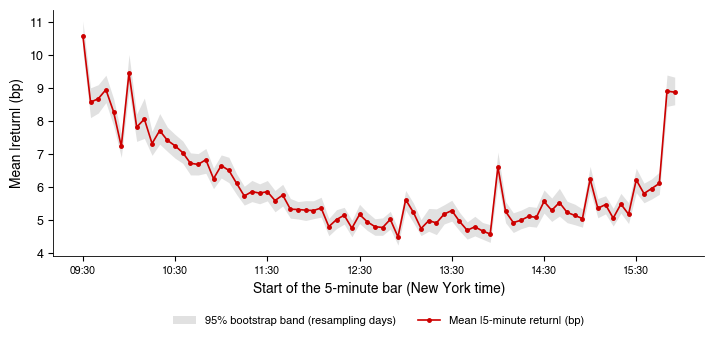

{'ratio': np.float64(2.0611100241206155),
 'lo': 1.9800262772534618,
 'hi': 2.154720227869524,
 'open': np.float64(10.590414985574784),
 'mid': np.float64(5.138209441338895),
 'vshare': np.float64(18.64671431741261),
 'vlo': 18.32366443924597,
 'vhi': 18.985597110968445,
 'n': 1477,
 'absr_close': 8.879817050739323}

In [16]:
# Solution
def b1_ushape():
    s = intraday_spy()
    x = s.dropna(subset=['r'])
    by_day = {}
    for d, g in x.groupby('date'):
        g = g.set_index('tod')
        by_day[d] = (abs(g['r'].get('09:30', np.nan)), g.loc['11:30':'14:00', 'r'].abs().mean(),
                     g['volume'].iloc[-6:].sum() / g['volume'].sum())
    arr = np.array(list(by_day.values()))
    ratio = np.nanmean(arr[:, 0]) / np.nanmean(arr[:, 1])
    lo, hi = boot_days(by_day, lambda v: np.nanmean([a[0] for a in v]) / np.nanmean([a[1] for a in v]))
    vs = np.nanmean(arr[:, 2])
    vlo, vhi = boot_days(by_day, lambda v: np.nanmean([a[2] for a in v]))
    tod = spy_tod(s)
    # grafic: media |r| pe intervale, cu benzi bootstrap pe zile
    piv = x.pivot_table(index='date', columns='tod', values='r', aggfunc=lambda v: abs(v).mean())
    rng = np.random.default_rng(SEED)
    bs = np.array([piv.iloc[rng.integers(0, len(piv), len(piv))].mean().values for _ in range(300)])
    lo_b, hi_b = 1e4 * np.nanpercentile(bs, 2.5, axis=0), 1e4 * np.nanpercentile(bs, 97.5, axis=0)
    k = np.arange(len(piv.columns))
    fig, ax = plt.subplots(figsize=(8.4, 3.2))
    ax.fill_between(k, lo_b, hi_b, color='#DADADA', alpha=0.8, lw=0, label='95% bootstrap band (resampling days)')
    ax.plot(k, 1e4 * piv.mean().values, color=IDAred, lw=1.2, marker='o', ms=2.5, label='Mean |5-minute return| (bp)')
    ax.set_xticks(k[::12])
    ax.set_xticklabels(piv.columns[::12], fontsize=7.5)
    ax.set_xlabel('Start of the 5-minute bar (New York time)')
    ax.set_ylabel('Mean |return| (bp)')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch10_sem_ushape')
    return dict(ratio=ratio, lo=lo, hi=hi, open=1e4 * np.nanmean(arr[:, 0]), mid=1e4 * np.nanmean(arr[:, 1]),
                vshare=100 * vs, vlo=100 * vlo, vhi=100 * vhi, n=len(by_day), absr_close=float(tod['absr'].iloc[-1]))


b1_ushape()

### B2. Spread Estimators at Two Frequencies [Solved]

**Context and assumptions**

- SPY 5-minute bars (`data/market/intraday/SPY.US_5m.csv`), regular session 09:30–16:00 New York time, only full days with 78 bars: 1 477 days, October 2020 – September 2026.
- Daily SPY bars from `data/market/SPY.US.csv` (prices adjusted for dividends), September 2024 – September 2026. One tick is USD 0.01.

**Sub-tasks**

- (a) Compute the Roll, Corwin–Schultz and Abdi–Ranaldo estimators within each day from the 5-minute bars, average them over days, and give 95% day-bootstrap intervals (1 000 resamples) [Roll (1984)](https://doi.org/10.1111/j.1540-6261.1984.tb03897.x), [Corwin & Schultz (2012)](https://doi.org/10.1111/j.1540-6261.2012.01729.x), [Abdi & Ranaldo (2017)](https://doi.org/10.1093/rfs/hhx084).
- (b) Compute the same estimators from the daily bars, with a moving-block bootstrap (blocks of 20 days, 1 000 resamples).
- (c) Compare every estimate with one tick relative to the price.
- (d) Simulate the Roll model with SPY's bar volatility and 78 prices a day (1 477 days per sample, 200 samples), for a one-tick spread and for $c = 0$; compute the share of days with $\hat\gamma_1 > 0$ and the pooled estimate [Harris (1990)](https://doi.org/10.1111/j.1540-6261.1990.tb03704.x).

**Report and interpret**

- A table of estimates with intervals, and the Monte Carlo results next to the observed ones.
- Interpretation: which frequency gives a credible spread; what do the daily estimators measure; is the share of positive covariances evidence against the Roll model?

In [17]:
# Solution
def b2_spreads():
    s = intraday_spy()
    E = intraday_spreads(s)
    by_day = {d: row for d, row in E.iterrows()}
    roll5 = 1e4 * 2 * np.sqrt(max(-E['cov'].mean(), 0))
    rlo, rhi = boot_days(by_day, lambda v: 1e4 * 2 * np.sqrt(max(-np.mean([r['cov'] for r in v]), 0)))
    cs5 = 1e4 * E['cs'].mean()
    clo, chi = boot_days(by_day, lambda v: 1e4 * np.mean([r['cs'] for r in v]))
    ar5 = 1e4 * np.sqrt(max(E['ar2'].mean(), 0))
    alo, ahi = boot_days(by_day, lambda v: 1e4 * np.sqrt(max(np.mean([r['ar2'] for r in v]), 0)))
    tick = 1e4 * (0.01 / E['price']).mean()
    # date zilnice: bootstrap pe blocuri mobile de 20 de zile
    d = ohlc('SPY', START2)
    cs = cs_spread(d['high'], d['low'])
    ar2 = ar_terms(d['close'], d['high'], d['low'])
    rng = np.random.default_rng(SEED)
    n, L = len(cs), 20
    csb, arb = [], []
    for _ in range(B):
        st = rng.integers(0, n - L, n // L + 1)
        idx = np.concatenate([np.arange(a, a + L) for a in st])[:n]
        csb.append(1e4 * cs[idx].mean())
        arb.append(1e4 * np.sqrt(max(ar2[idx].mean(), 0)))
    sd_daily = 1e4 * np.log(d['close']).diff().std()
    return dict(roll5=roll5, rlo=rlo, rhi=rhi, cs5=cs5, clo=clo, chi=chi, ar5=ar5, alo=alo, ahi=ahi, tick=tick,
                cs_d=1e4 * cs.mean(), cs_dlo=float(np.percentile(csb, 2.5)), cs_dhi=float(np.percentile(csb, 97.5)),
                ar_d=1e4 * np.sqrt(max(ar2.mean(), 0)), ar_dlo=float(np.percentile(arb, 2.5)),
                ar_dhi=float(np.percentile(arb, 97.5)), sd_daily=sd_daily, share_negcov=float((E['cov'] < 0).mean()))


b2_spreads()

{'roll5': np.float64(2.8178694948515814),
 'rlo': 2.088525758122144,
 'rhi': 3.4255275546874655,
 'cs5': np.float64(3.114235796578159),
 'clo': 3.0289837140441147,
 'chi': 3.2013723971846413,
 'ar5': np.float64(1.0597709930490853),
 'alo': 0.0,
 'ahi': 1.667760884627947,
 'tick': np.float64(0.2065684865019977),
 'cs_d': np.float64(22.390237058522164),
 'cs_dlo': 17.42412538028882,
 'cs_dhi': 29.449564938969115,
 'ar_d': np.float64(55.09545779283073),
 'ar_dlo': 0.0,
 'ar_dhi': 92.63874164256617,
 'sd_daily': 103.3794289113439,
 'share_negcov': 0.5924170616113744}

In [18]:
# (d) Monte Carlo of the Roll model (Harris, 1990)
roll_small_sample(intraday_spreads(intraday_spy()))

{'pos_obs': 0.4075829383886256,
 'n_days': 1477,
 'sd_bar': 9.1583127862955,
 'c_tick': 0.10328424325099884,
 'pos_tick': 0.45316181448882875,
 'pos_tick_lo': 0.4299255247122546,
 'pos_tick_hi': 0.4808395396073122,
 'roll_tick': 2.0730377581893937,
 'roll_tick_lo': 1.5056679955636603,
 'roll_tick_hi': 2.53365546070691,
 'pos_zero': 0.4533243060257279,
 'pos_zero_lo': 0.4312796208530806,
 'pos_zero_hi': 0.4828199052132701,
 'roll_zero': 2.0625393126665523,
 'roll_zero_lo': 1.4988282803065303,
 'roll_zero_hi': 2.526258631145369,
 'roll_corr': 1.9180237793613462,
 'roll5': 2.8178694948515814}

### B3. Spread Estimates Across 25 Assets [Proposed]

**Context and assumptions**

- Daily open, high, low, close and volume, September 2024 – September 2026, from `data/market`: 7 US stocks and ETFs, 11 BVB stocks and the BET ETF group, 7 crypto-assets (25 assets).
- Volatility annualised with 252 days for stocks and 365 for crypto; the Amihud ratio as in the lecture (bp per USD 1 million).

**Sub-tasks**

- (a) Compute Corwin–Schultz and Abdi–Ranaldo for each asset from daily bars, and the median of each group.
- (b) Compute the Spearman rank correlations of Corwin–Schultz with annualised volatility, of the Amihud ratio with the median traded value, and of Corwin–Schultz with Amihud.
- (c) Count the assets for which Abdi–Ranaldo is set to 0.

**Report and interpret**

- Group medians, the three correlations and the scatter plots.
- Interpretation: do BVB stocks look more or less liquid than US stocks; which measure would you trust to compare markets; what would you need to validate it?
- **Model**: B2

In [ ]:
# Your code here


### B4. Illiquidity and the VIX [Solved]

**Context and assumptions**

- SPY 5-minute bars (`data/market/intraday/SPY.US_5m.csv`), regular session 09:30–16:00 New York time, only full days with 78 bars: 1 477 days, October 2020 – September 2026.
- Daily intraday illiquidity $\mathrm{ILLIQ}_d$: the mean over the 78 bars of $|r|$ divided by the traded value, in bp per USD 100 million; VIX daily close from `data/market/VIX.INDX.csv`; 1 477 common days.

**Sub-tasks**

- (a) Estimate by OLS $\ln\mathrm{ILLIQ}_d = a + b\ln\mathrm{VIX}_d + e_d$.
- (b) Report OLS and HAC (Newey–West, 20 lags) standard errors, the 95% HAC interval, and the first-order autocorrelation of the residuals [Newey & West (1987)](https://doi.org/10.2307/1913610).
- (c) Add a linear time trend (in years) and re-estimate $b$ with HAC errors.
- (d) Test the stability of $b$: interact $\ln\mathrm{VIX}$ with a dummy for the second half of the sample (date fixed before estimation) and run a HAC Wald test at the 5% level.

**Report and interpret**

- $\hat b$ with both standard errors, the trend regression and the break test.
- Interpretation: read $b$ as an elasticity; why do the standard errors differ; is the elasticity stable; is the relation causal?

In [20]:
# Solution
def b4_illiq_vix():
    s = intraday_spy()
    ill = spy_illiq_daily(s)
    vix = read_market('VIX.INDX')['close'].rename('vix')
    j = pd.concat([ill, vix], axis=1, join='inner').dropna()
    y, X = np.log(j['illiq']), sm.add_constant(np.log(j['vix']))
    ols = sm.OLS(y, X).fit()
    hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    # control pentru nivelul valorii tranzactionate (tendinta)
    dvd = s.groupby('date')['dv'].sum().rename('dv')
    j2 = pd.concat([j, dvd], axis=1, join='inner').dropna()
    X2 = sm.add_constant(pd.DataFrame({'lvix': np.log(j2['vix']), 't': np.arange(len(j2)) / 252}))
    hac2 = sm.OLS(np.log(j2['illiq']), X2).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    rho1 = float(np.corrcoef(ols.resid[1:], ols.resid[:-1])[0, 1])
    # (d) stabilitatea elasticitatii: ruptura la mijlocul esantionului (data fixata inainte de estimare), test Wald HAC
    mid = j.index[len(j) // 2]
    post = (j.index >= mid).astype(float)
    X3 = sm.add_constant(pd.DataFrame({'lvix': np.log(j['vix']), 'post': post, 'lvix_post': post * np.log(j['vix'])},
                                      index=j.index))
    hac3 = sm.OLS(y, X3).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
    w = hac3.wald_test('lvix_post = 0', scalar=True)
    return dict(b=float(hac.params.iloc[1]), se_ols=float(ols.bse.iloc[1]), se_hac=float(hac.bse.iloc[1]),
                brk=mid.strftime('%Y-%m-%d'), b_pre=float(hac3.params['lvix']),
                b_post=float(hac3.params['lvix'] + hac3.params['lvix_post']), d_brk=float(hac3.params['lvix_post']),
                se_brk=float(hac3.bse['lvix_post']), p_brk=float(w.pvalue),
                lo=float(hac.params.iloc[1] - 1.96 * hac.bse.iloc[1]), hi=float(hac.params.iloc[1] + 1.96 * hac.bse.iloc[1]),
                r2=float(ols.rsquared), n=int(len(j)), rho1=rho1, b2=float(hac2.params['lvix']),
                se2=float(hac2.bse['lvix']), trend=float(hac2.params['t']), se_trend=float(hac2.bse['t']))


b4_illiq_vix()

{'b': 0.9544304059527832,
 'se_ols': 0.03762559414053015,
 'se_hac': 0.12116131927996482,
 'brk': '2023-09-27',
 'b_pre': 1.029337759489565,
 'b_post': 0.5962705134490079,
 'd_brk': -0.433067246040557,
 'se_brk': 0.25435796505618935,
 'p_brk': 0.08864488292106393,
 'lo': 0.7169542201640522,
 'hi': 1.1919065917415141,
 'r2': 0.30373962833787016,
 'n': 1477,
 'rho1': 0.7589592718584635,
 'b2': 0.8042733818184661,
 'se2': 0.12031769162600765,
 'trend': -0.0616845891503183,
 'se_trend': 0.021082133375156693}

### B5. Amihud Illiquidity on Three Markets [Proposed]

**Context and assumptions**

- The 25 assets of B3; daily Amihud ratio $|r_d|/\mathrm{DVOL}_d$ in bp per USD 1 million, averaged over September 2024 – September 2026 [Amihud (2002)](https://doi.org/10.1016/S1386-4181(01)00024-6).
- BVB traded value converted to USD at the BNR reference rate of each day.

**Sub-tasks**

- (a) Compute the median Amihud ratio of each group and the ratio BVB median / US median.
- (b) Build a 95% bootstrap interval for that ratio by resampling assets within each group (1 000 resamples).
- (c) Compute the Spearman correlation between the asset rankings of the first and the second year.

**Report and interpret**

- The medians, the ratio with its interval and the rank correlation.
- Interpretation: how much less liquid is the BVB, how precise is that number, and is illiquidity a stable characteristic?
- **Model**: B2, B4

In [ ]:
# Your code here


### B6. Volume and Price Moves in SPY Bars [Proposed]

**Context and assumptions**

- SPY 5-minute bars (`data/market/intraday/SPY.US_5m.csv`), regular session 09:30–16:00 New York time, only full days with 78 bars: 1 477 days, October 2020 – September 2026.
- Relative volume = bar volume / median volume at the same time of day; $z = |r|$ divided by the day's standard deviation of 5-minute returns; 115 052 bars.

**Sub-tasks**

- (a) Sort bars into 20 equal-size groups by relative volume, regress $\ln\bar z$ on $\ln$ mean relative volume, and give a 95% day-bootstrap interval for the slope (300 resamples).
- (b) At bar level, regress $\ln|r| - \ln\sigma_{\text{day}}$ on $\ln$ relative volume with standard errors clustered by day, and test slope $= 0.5$ at 5%.
- (c) IV (Instrumental Variable): instrument $\ln$ relative volume by the log relative volume of the same bar on the previous day; report the first stage, the two-stage least squares slope and its clustered SE.

**Report and interpret**

- The grouped and bar-level slopes, the $t$ statistic against 0.5, and the IV results.
- Interpretation: is the relation concave, is it the square-root law [Tóth et al. (2011)](https://doi.org/10.1103/PhysRevX.1.021006), why cluster by day, and is the exclusion restriction of (c) plausible?
- **Model**: B4

In [ ]:
# Your code here


### B7. The Bitcoin Clock [Proposed]

**Context and assumptions**

- Bitcoin 5-minute bars (`data/market/intraday/BTC-USD.CC_5m.csv`), UTC, September 2024 – September 2026: 749 days, trading 24 hours a day, 7 days a week.

**Sub-tasks**

- (a) On weekdays, compute the mean $|r|$ in 13:00–17:00 UTC (US morning) and in 03:00–11:00 UTC (Asian and European morning), and their ratio with a 95% day-bootstrap interval (1 000 resamples).
- (b) Compute the ratio of weekday to weekend mean $|r|$ with a 95% day-bootstrap interval.

**Report and interpret**

- The two ratios with intervals.
- Interpretation: why does a 24/7 market have a clock, and when would you execute a large Bitcoin order?
- **Model**: B1

In [ ]:
# Your code here


### B8. Price Discovery, the BET ETF and the BET-TR Index [Proposed]

**Context and assumptions**

- Daily log closes of the Patria-TVBETETF (`data/market/TVBETETF.RO.csv`, days with trades) and of BET-TR (`data/market/BETTR.INDX.csv`), common days, September 2024 – September 2026 (lecture, Section 10).
- The ETF reinvests dividends, so it should be cointegrated with BET-TR with vector $\beta = (1, -1)'$.

**Sub-tasks**

- (a) Run the Johansen trace test [Johansen (1991)](https://doi.org/10.2307/2938278), then estimate the VECM with $\beta = (1, -1)'$ imposed and lags chosen by BIC; test $\alpha_{\mathrm{ETF}} = 0$ and $\alpha_{\mathrm{idx}} = 0$ at 5%.
- (b) Compute the Hasbrouck information-share bounds [Hasbrouck (1995)](https://doi.org/10.1111/j.1540-6261.1995.tb04054.x) and the Gonzalo–Granger component share [Gonzalo & Granger (1995)](https://doi.org/10.1080/07350015.1995.10524576), with 95% moving-block bootstrap intervals (blocks of 20 days, 1 000 resamples).
- (c) Re-estimate both $\alpha$ on each half of the sample.

**Report and interpret**

- The adjustment coefficients with $t$ statistics and intervals, the share bounds, and the two half-samples.
- Interpretation: which venue leads and how sure are you; why are the bounds so wide at daily frequency; why can the component share leave $[0, 1]$?
- **Model**: B4

In [ ]:
# Your code here


### C1. Does Illiquidity Carry a Premium on the BVB? [Proposed]

**Context and assumptions**

- Open question and seed for the team project: how illiquid is the BVB compared with US and crypto markets, and is illiquidity priced?
- Amihud (2002): expected illiquidity should **raise** future returns; an unexpected rise should **lower** current returns [Amihud (2002)](https://doi.org/10.1016/S1386-4181(01)00024-6).
- Data: monthly BET-TR, SPY and Bitcoin returns from `data/market`; market illiquidity from the stocks (tokens) of each market, 2016–2026.

**Sub-tasks**

- (a) Build a monthly market illiquidity index (cross-sectional mean of log Amihud, months with at least 10 trading days) and its shock, the residual of an AR(1).
- (b) Regress monthly returns on lagged illiquidity and the shock, with HAC standard errors (6 lags), and correct the lagged coefficient for the Stambaugh bias [Stambaugh (1999)](https://doi.org/10.1016/S0304-405X(99)00041-0) with the reduced-bias estimator [Amihud & Hurvich (2004)](https://doi.org/10.1017/S0022109000003227).
- (c) On the BVB, form the illiquid-minus-liquid half of the ten blue chips, rebalanced every year, and test its mean return.

**Report and interpret**

- A table per market, the scatter of returns on shocks, and a discussion of power: few stocks, ten years [Pele, Mazurencu-Marinescu & Nijkamp (2013)](https://doi.org/10.2139/ssrn.2305945).
- Interpretation: which of Amihud's two predictions survives on each market?

In [ ]:
# Your code here
